In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F  
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve, average_precision_score, recall_score, precision_score)
from sklearn.utils.class_weight import compute_class_weight
import timm
import faiss
from sentence_transformers import SentenceTransformer
import joblib
import warnings
warnings.filterwarnings("ignore")

# Data Collection and Loading

In [3]:
df = pd.read_csv(r"D:\Diabetic Retinopathy Detection\kaggle (Diabetic Retinopathy Detection and Classification)\train.csv")
base_dir = Path(r'D:\Diabetic Retinopathy Detection\kaggle (Diabetic Retinopathy Detection and Classification)\gaussian_filtered_images')

class_map = {0: 'No_DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferate_DR'}

def get_class_path(row):
    cls_name = class_map[row['diagnosis']]
    return str(base_dir / cls_name / f"{row['id_code']}.png")

df['image_path'] = df.apply(get_class_path, axis=1)

# Binary label: 0 = No DR, 1 = Any DR
df['binary_label'] = df['diagnosis'].apply(lambda x: 0 if x == 0 else 1)

# Exploratory Data Analysis (EDA)

# Binary Distribution Bar Plot

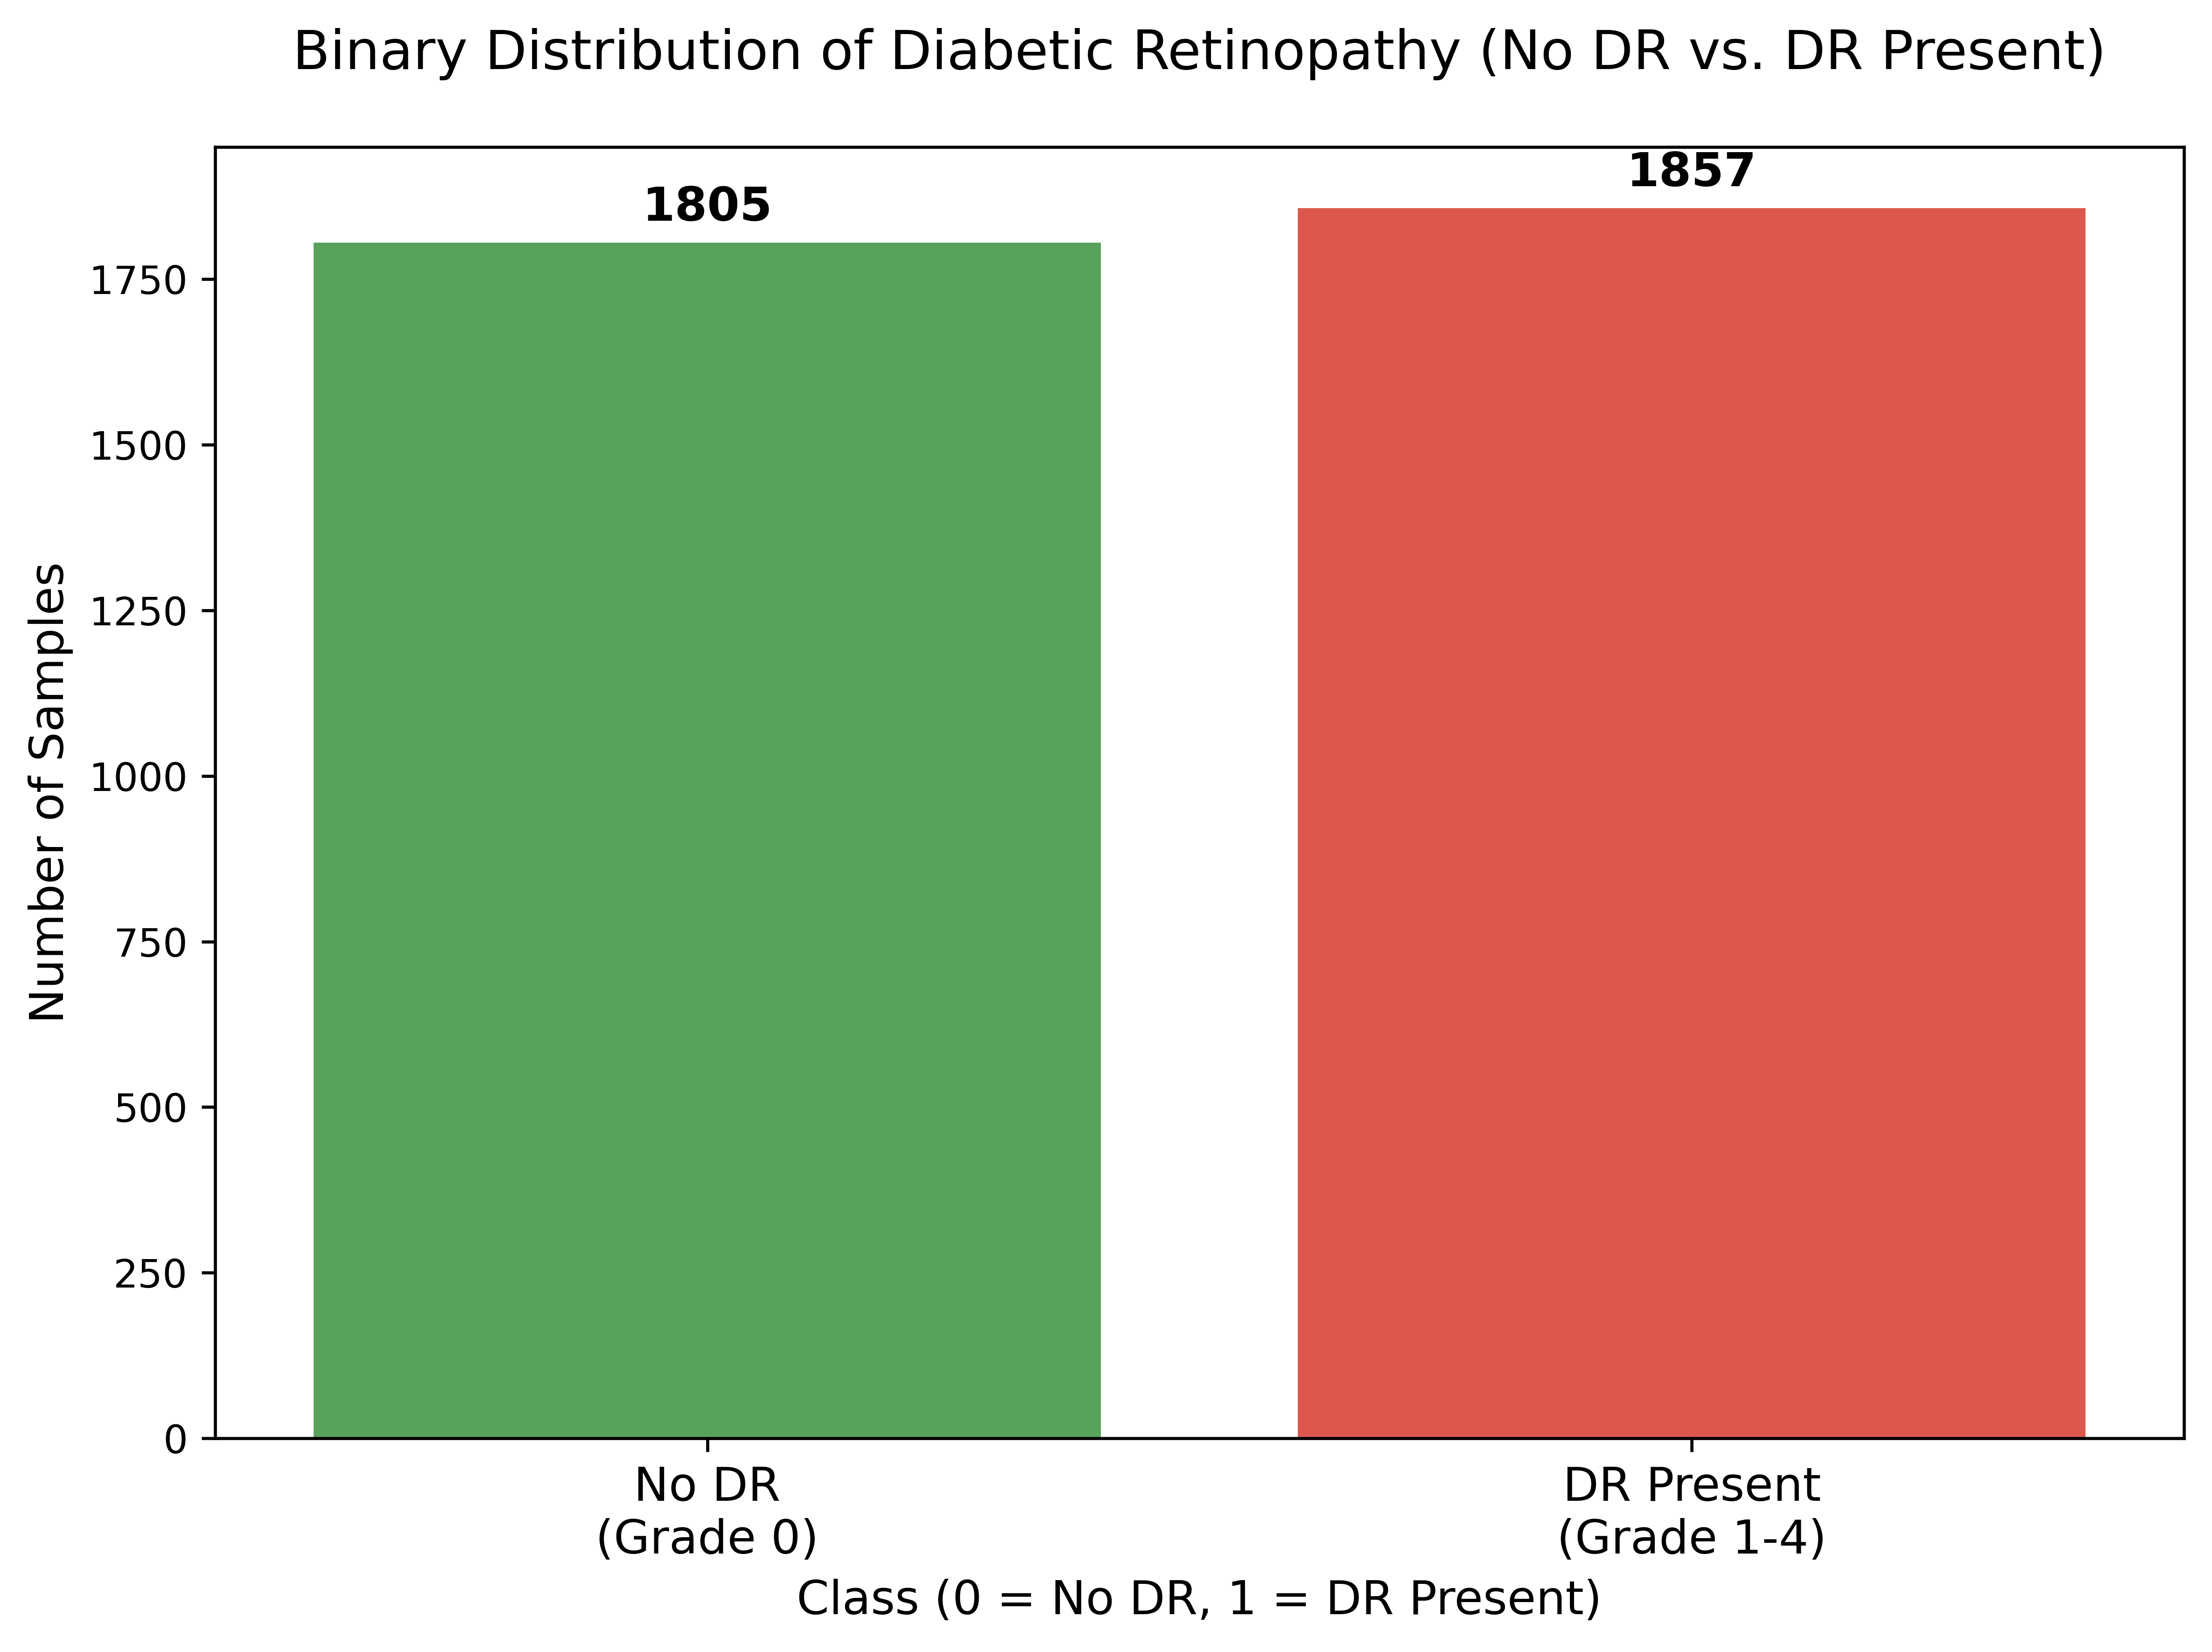

Binary classification sample distribution：
binary_label
0    1805
1    1857
Name: count, dtype: int64
Total samples: 3662
No DR (0): 1805 (49.290%)
DR Present (1): 1857 (50.710%)


In [4]:
plt.figure(figsize=(8, 6), dpi=600)
sns.countplot(x='binary_label', data=df, palette=['#4CAF50', '#F44336'])
plt.title('Binary Distribution of Diabetic Retinopathy (No DR vs. DR Present)', fontsize=14, pad=20)
plt.xlabel('Class (0 = No DR, 1 = DR Present)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.xticks([0, 1], ['No DR\n(Grade 0)', 'DR Present\n(Grade 1-4)'], fontsize=12)
plt.tight_layout()
plt.show()

print("Binary classification sample distribution：")
print(df['binary_label'].value_counts().sort_index())
print(f"Total samples: {len(df)}")
print(f"No DR (0): {df['binary_label'].value_counts()[0]} ({df['binary_label'].value_counts(normalize=True)[0]:.3%})")
print(f"DR Present (1): {df['binary_label'].value_counts()[1]} ({df['binary_label'].value_counts(normalize=True)[1]:.3%})")

# Sample Images Visualization

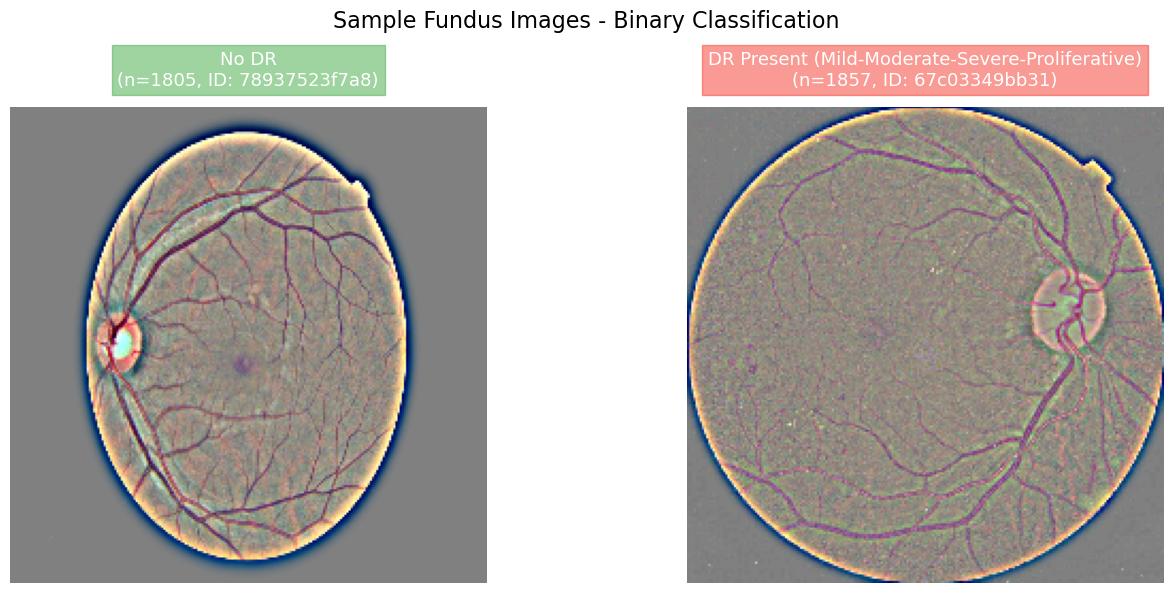

Successfully loaded 2/2 images


In [5]:
binary_classes = [0, 1]
class_names = {0: 'No DR', 1: 'DR Present (Mild-Moderate-Severe-Proliferative)'}
colors = ['#4CAF50', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
loaded_count = 0

for i, cls in enumerate(binary_classes):
    class_df = df[df['binary_label'] == cls]
    if len(class_df) == 0:
        axes[i].text(0.5, 0.5, f'No Samples\n{class_names[cls]}', ha='center', va='center',
                     transform=axes[i].transAxes, fontsize=14, color='white')
        axes[i].set_facecolor('black')
    else:
        sample = class_df.sample(1).iloc[0]
        img_path = sample['image_path']
        if not os.path.exists(img_path):
            img_placeholder = np.zeros((224, 224, 3), dtype=np.uint8)
            axes[i].imshow(img_placeholder)
            axes[i].text(112, 112, 'Missing\nImage', ha='center', va='center', color='white', fontsize=14)
        else:
            img = Image.open(img_path).convert('RGB')
            axes[i].imshow(img)
            loaded_count += 1
    
    sample_count = len(class_df)
    axes[i].set_title(f'{class_names[cls]}\n(n={sample_count}, ID: {sample["id_code"]})',
                      fontsize=13, pad=15, backgroundcolor=colors[i]+'88', color='white')
    axes[i].axis('off')

plt.suptitle('Sample Fundus Images - Binary Classification', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

print(f"Successfully loaded {loaded_count}/2 images")

# Generate Synthetic Clinical Data

In [6]:
np.random.seed(42)
n_samples = len(df)

df['age'] = np.random.randint(30, 80, n_samples)
df.loc[df['binary_label'] == 1, 'age'] += np.random.randint(0, 15, sum(df['binary_label'] == 1))

df['duration_diabetes'] = np.where(
    df['binary_label'] == 0,
    np.random.randint(1, 15, n_samples),
    np.random.randint(10, 30, n_samples)
)

df['hba1c'] = np.where(
    df['binary_label'] == 0,
    6.5 + np.random.normal(0, 0.8, n_samples),
    8.8 + np.random.normal(0, 1.2, n_samples)
)
df['hba1c'] = df['hba1c'].clip(5.0, 14.0)

df['blood_pressure_systolic'] = np.where(
    df['binary_label'] == 0,
    np.random.randint(110, 140, n_samples),
    np.random.randint(130, 170, n_samples)
)

has_ht_prob = np.where(df['binary_label'] == 0, 0.3, 0.6)
df['has_hypertension'] = np.random.binomial(1, has_ht_prob)

clinical_cols = ['age', 'duration_diabetes', 'hba1c', 'blood_pressure_systolic', 'has_hypertension']

# Dataset split

In [7]:
class BinaryDRDataset(Dataset):
    def __init__(self, df, clinical_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.clinical_cols = clinical_cols
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        clinical = torch.tensor(row[self.clinical_cols].values.astype(np.float32))
        label = torch.tensor(row['binary_label'], dtype=torch.long)
        return img, clinical, label

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = BinaryDRDataset(df, clinical_cols, transform=transform)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_ds, test_ds = random_split(full_dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

# Data Standardization

In [8]:
train_indices = train_ds.indices
test_indices = test_ds.indices

scaler = StandardScaler()
train_clinical_scaled = scaler.fit_transform(df.loc[train_indices, clinical_cols])
test_clinical_scaled = scaler.transform(df.loc[test_indices, clinical_cols])

df.loc[train_indices, clinical_cols] = train_clinical_scaled
df.loc[test_indices, clinical_cols] = test_clinical_scaled

joblib.dump(scaler, 'binary_clinical_scaler.pkl')

['binary_clinical_scaler.pkl']

# Clinical Features Boxplots

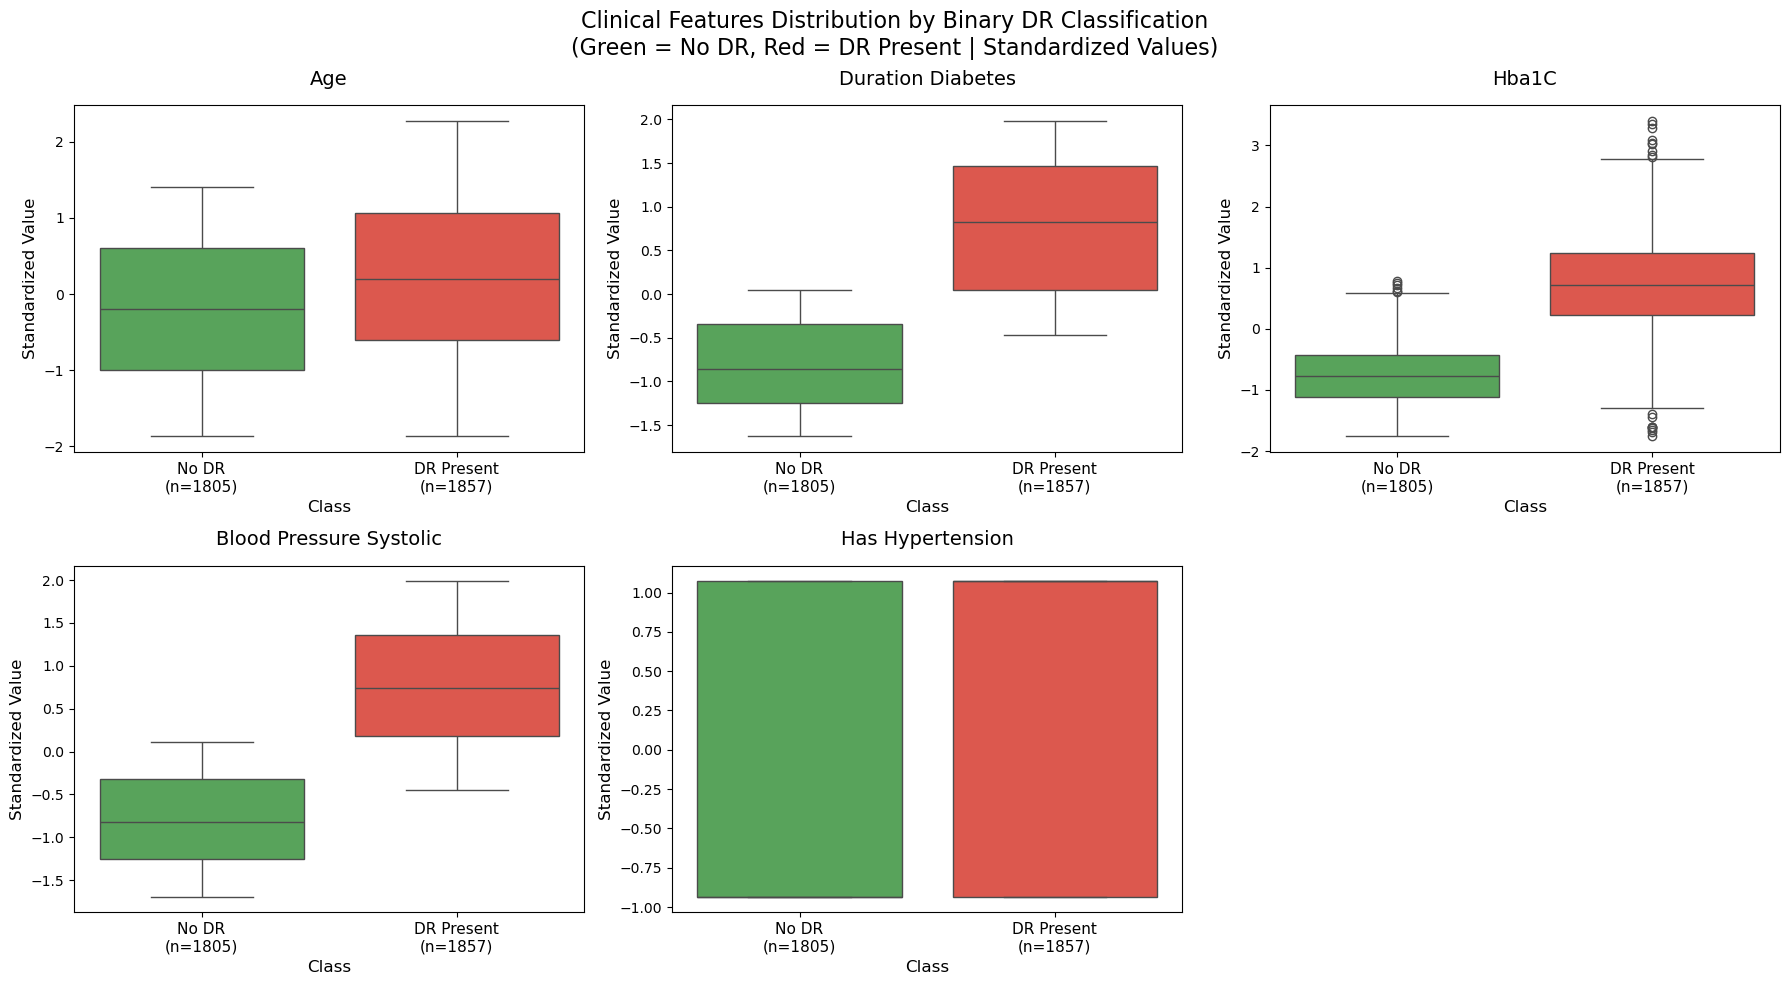

Summary of mean values of binary clinical characteristics：
                 age  duration_diabetes   hba1c  blood_pressure_systolic  \
binary_label                                                               
0            -0.2174            -0.7806 -0.7670                  -0.7885   
1             0.2254             0.7542  0.7411                   0.7680   

              has_hypertension  
binary_label                    
0                      -0.2983  
1                       0.2604  


In [9]:
n_features = len(clinical_cols)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(clinical_cols):
    sns.boxplot(x='binary_label', y=col, data=df, ax=axes[i], hue='binary_label',
                palette={0: '#4CAF50', 1: '#F44336'}, legend=False)  
    
    axes[i].set_title(col.replace("_", " ").title(), fontsize=14, pad=15)
    axes[i].set_xlabel('Class', fontsize=12)
    axes[i].set_ylabel('Standardized Value', fontsize=12)
    axes[i].set_xticklabels([f'No DR\n(n={len(df[df["binary_label"]==0])})',
                             f'DR Present\n(n={len(df[df["binary_label"]==1])})'], fontsize=11)
    
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Clinical Features Distribution by Binary DR Classification\n'
             '(Green = No DR, Red = DR Present | Standardized Values)', 
             fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

print("Summary of mean values of binary clinical characteristics：")
print(df.groupby('binary_label')[clinical_cols].mean().round(4))

# Balanced sampling for training

In [10]:
train_labels = [full_dataset[i][2].item() for i in train_ds.indices]
class_counts = np.bincount(train_labels)
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Model Architecture

In [11]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import torch  

# Define device for tensor operations (GPU if available for faster training).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class BinaryDRDataset(Dataset):
    def __init__(self, df, clinical_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.clinical_cols = clinical_cols
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        clinical = torch.tensor(row[self.clinical_cols].values.astype(np.float32))
        label = torch.tensor(row['binary_label'], dtype=torch.long)
        return img, clinical, label

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = BinaryDRDataset(df, clinical_cols, transform=transform)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_ds, test_ds = random_split(full_dataset, [train_size, test_size])

train_labels = [full_dataset[i][2].item() for i in train_ds.indices]
class_counts = np.bincount(train_labels)
class_weights_sample = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = class_weights_sample[train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)     
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


class BinaryDRModel(nn.Module):
    def __init__(self, clinical_dim=5, feature_dim=256):
        super().__init__()
        self.image_encoder = timm.create_model('convnextv2_tiny', pretrained=False, num_classes=0, in_chans=3)
        self.image_proj = nn.Linear(768, feature_dim)
        
        self.clinical_embedding = nn.Linear(clinical_dim, feature_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=feature_dim, nhead=8, dim_feedforward=512,
                                                   dropout=0.1, activation='gelu', batch_first=True)
        self.clinical_encoder = nn.TransformerEncoder(encoder_layer, num_layers=4)
        
        self.cross_attention = nn.MultiheadAttention(embed_dim=feature_dim, num_heads=8, dropout=0.1, batch_first=True)
        self.norm1 = nn.LayerNorm(feature_dim)
        self.norm2 = nn.LayerNorm(feature_dim)
        
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim * 2, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)   
        )
    
    def forward(self, img, clinical):
        img_feat = self.image_encoder(img)
        img_feat = self.image_proj(img_feat)
        
        clin = self.clinical_embedding(clinical).unsqueeze(1)
        clin_feat = self.clinical_encoder(clin).squeeze(1)
        
        img_q = self.norm1(img_feat).unsqueeze(1)
        clin_kv = self.norm2(clin_feat).unsqueeze(1)
        attn_out, _ = self.cross_attention(img_q, clin_kv, clin_kv)
        attn_out = attn_out.squeeze(1)
        
        fused = torch.cat([attn_out, clin_feat], dim=1)
        logits = self.classifier(fused)
        return logits


Using device: cpu


# Training the Model

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BinaryDRModel().to(device)
print(f"Using device: {device}")

weights = torch.tensor([1.0, 6.0], dtype=torch.float).to(device) 
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=1.5e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

def tta_predict(model, img, clin, flips=6):
    preds = [F.softmax(model(img, clin), dim=1)]
    for _ in range(flips):
        preds.append(F.softmax(model(torch.flip(img, dims=[3]), clin), dim=1))
    return torch.stack(preds).mean(0)

train_losses = []
test_losses = []
train_aucs = []
test_aucs = []
train_aps = []
test_aps = []

accum_steps = 8
num_epochs = 30
patience = 7
best_f1 = 0.0
epochs_no_improve = 0
best_model_path = 'best_binary_dr_model.pth'

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()
    
    for i, (img, clin, label) in enumerate(train_loader):
        img, clin, label = img.to(device), clin.to(device), label.to(device)
        out = model(img, clin)
        loss = criterion(out, label) / accum_steps
        loss.backward()
        
        if (i + 1) % accum_steps == 0 or (i + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        running_loss += loss.item() * accum_steps
    
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    test_loss = 0.0
    test_probs, test_labels = [], []
    with torch.no_grad():
        for img, clin, label in test_loader:
            img, clin = img.to(device), clin.to(device)
            out = tta_predict(model, img, clin, flips=4)
            loss = criterion(out, label.to(device))
            test_loss += loss.item()
            
            prob = out[:, 1].cpu().numpy()
            test_probs.extend(prob)
            test_labels.extend(label.cpu().numpy())
    
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    fpr, tpr, _ = roc_curve(test_labels, test_probs)
    test_auc = auc(fpr, tpr)
    test_aucs.append(test_auc)
    
    precision, recall, _ = precision_recall_curve(test_labels, test_probs)
    test_ap = average_precision_score(test_labels, test_probs)
    test_aps.append(test_ap)
    
    test_preds = (np.array(test_probs) > 0.5).astype(int)
    report = classification_report(test_labels, test_preds, output_dict=True, digits=4, zero_division=0)
    weighted_f1 = report['weighted avg']['f1-score']
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | "
          f"Test Weighted F1: {weighted_f1:.4f} | Test AUC: {test_auc:.4f}")
    
    if weighted_f1 > best_f1 + 1e-4:
        best_f1 = weighted_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  → New best model! F1 = {best_f1:.4f}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} | Best F1: {best_f1:.4f}")
            break

Using device: cpu
Epoch 01 | Train Loss: 0.3247 | Test Loss: 0.4207 | Test Weighted F1: 0.9864 | Test AUC: 0.9988
  → New best model! F1 = 0.9864
Epoch 02 | Train Loss: 0.2675 | Test Loss: 0.4288 | Test Weighted F1: 0.9864 | Test AUC: 0.9986
Epoch 03 | Train Loss: 0.2346 | Test Loss: 0.3962 | Test Weighted F1: 0.9877 | Test AUC: 0.9990
  → New best model! F1 = 0.9877
Epoch 04 | Train Loss: 0.2301 | Test Loss: 0.3966 | Test Weighted F1: 0.9877 | Test AUC: 0.9991
Epoch 05 | Train Loss: 0.2255 | Test Loss: 0.3961 | Test Weighted F1: 0.9877 | Test AUC: 0.9992
Epoch 06 | Train Loss: 0.2378 | Test Loss: 0.4090 | Test Weighted F1: 0.9700 | Test AUC: 0.9989
Epoch 07 | Train Loss: 0.2352 | Test Loss: 0.4064 | Test Weighted F1: 0.9795 | Test AUC: 0.9990
Epoch 08 | Train Loss: 0.2276 | Test Loss: 0.4002 | Test Weighted F1: 0.9864 | Test AUC: 0.9992
Epoch 09 | Train Loss: 0.2300 | Test Loss: 0.4094 | Test Weighted F1: 0.9877 | Test AUC: 0.9993
Epoch 10 | Train Loss: 0.2254 | Test Loss: 0.4008 | Te

# Evaluation metrics

The test set evaluation report has been saved：binary_dr_testset_report.csv


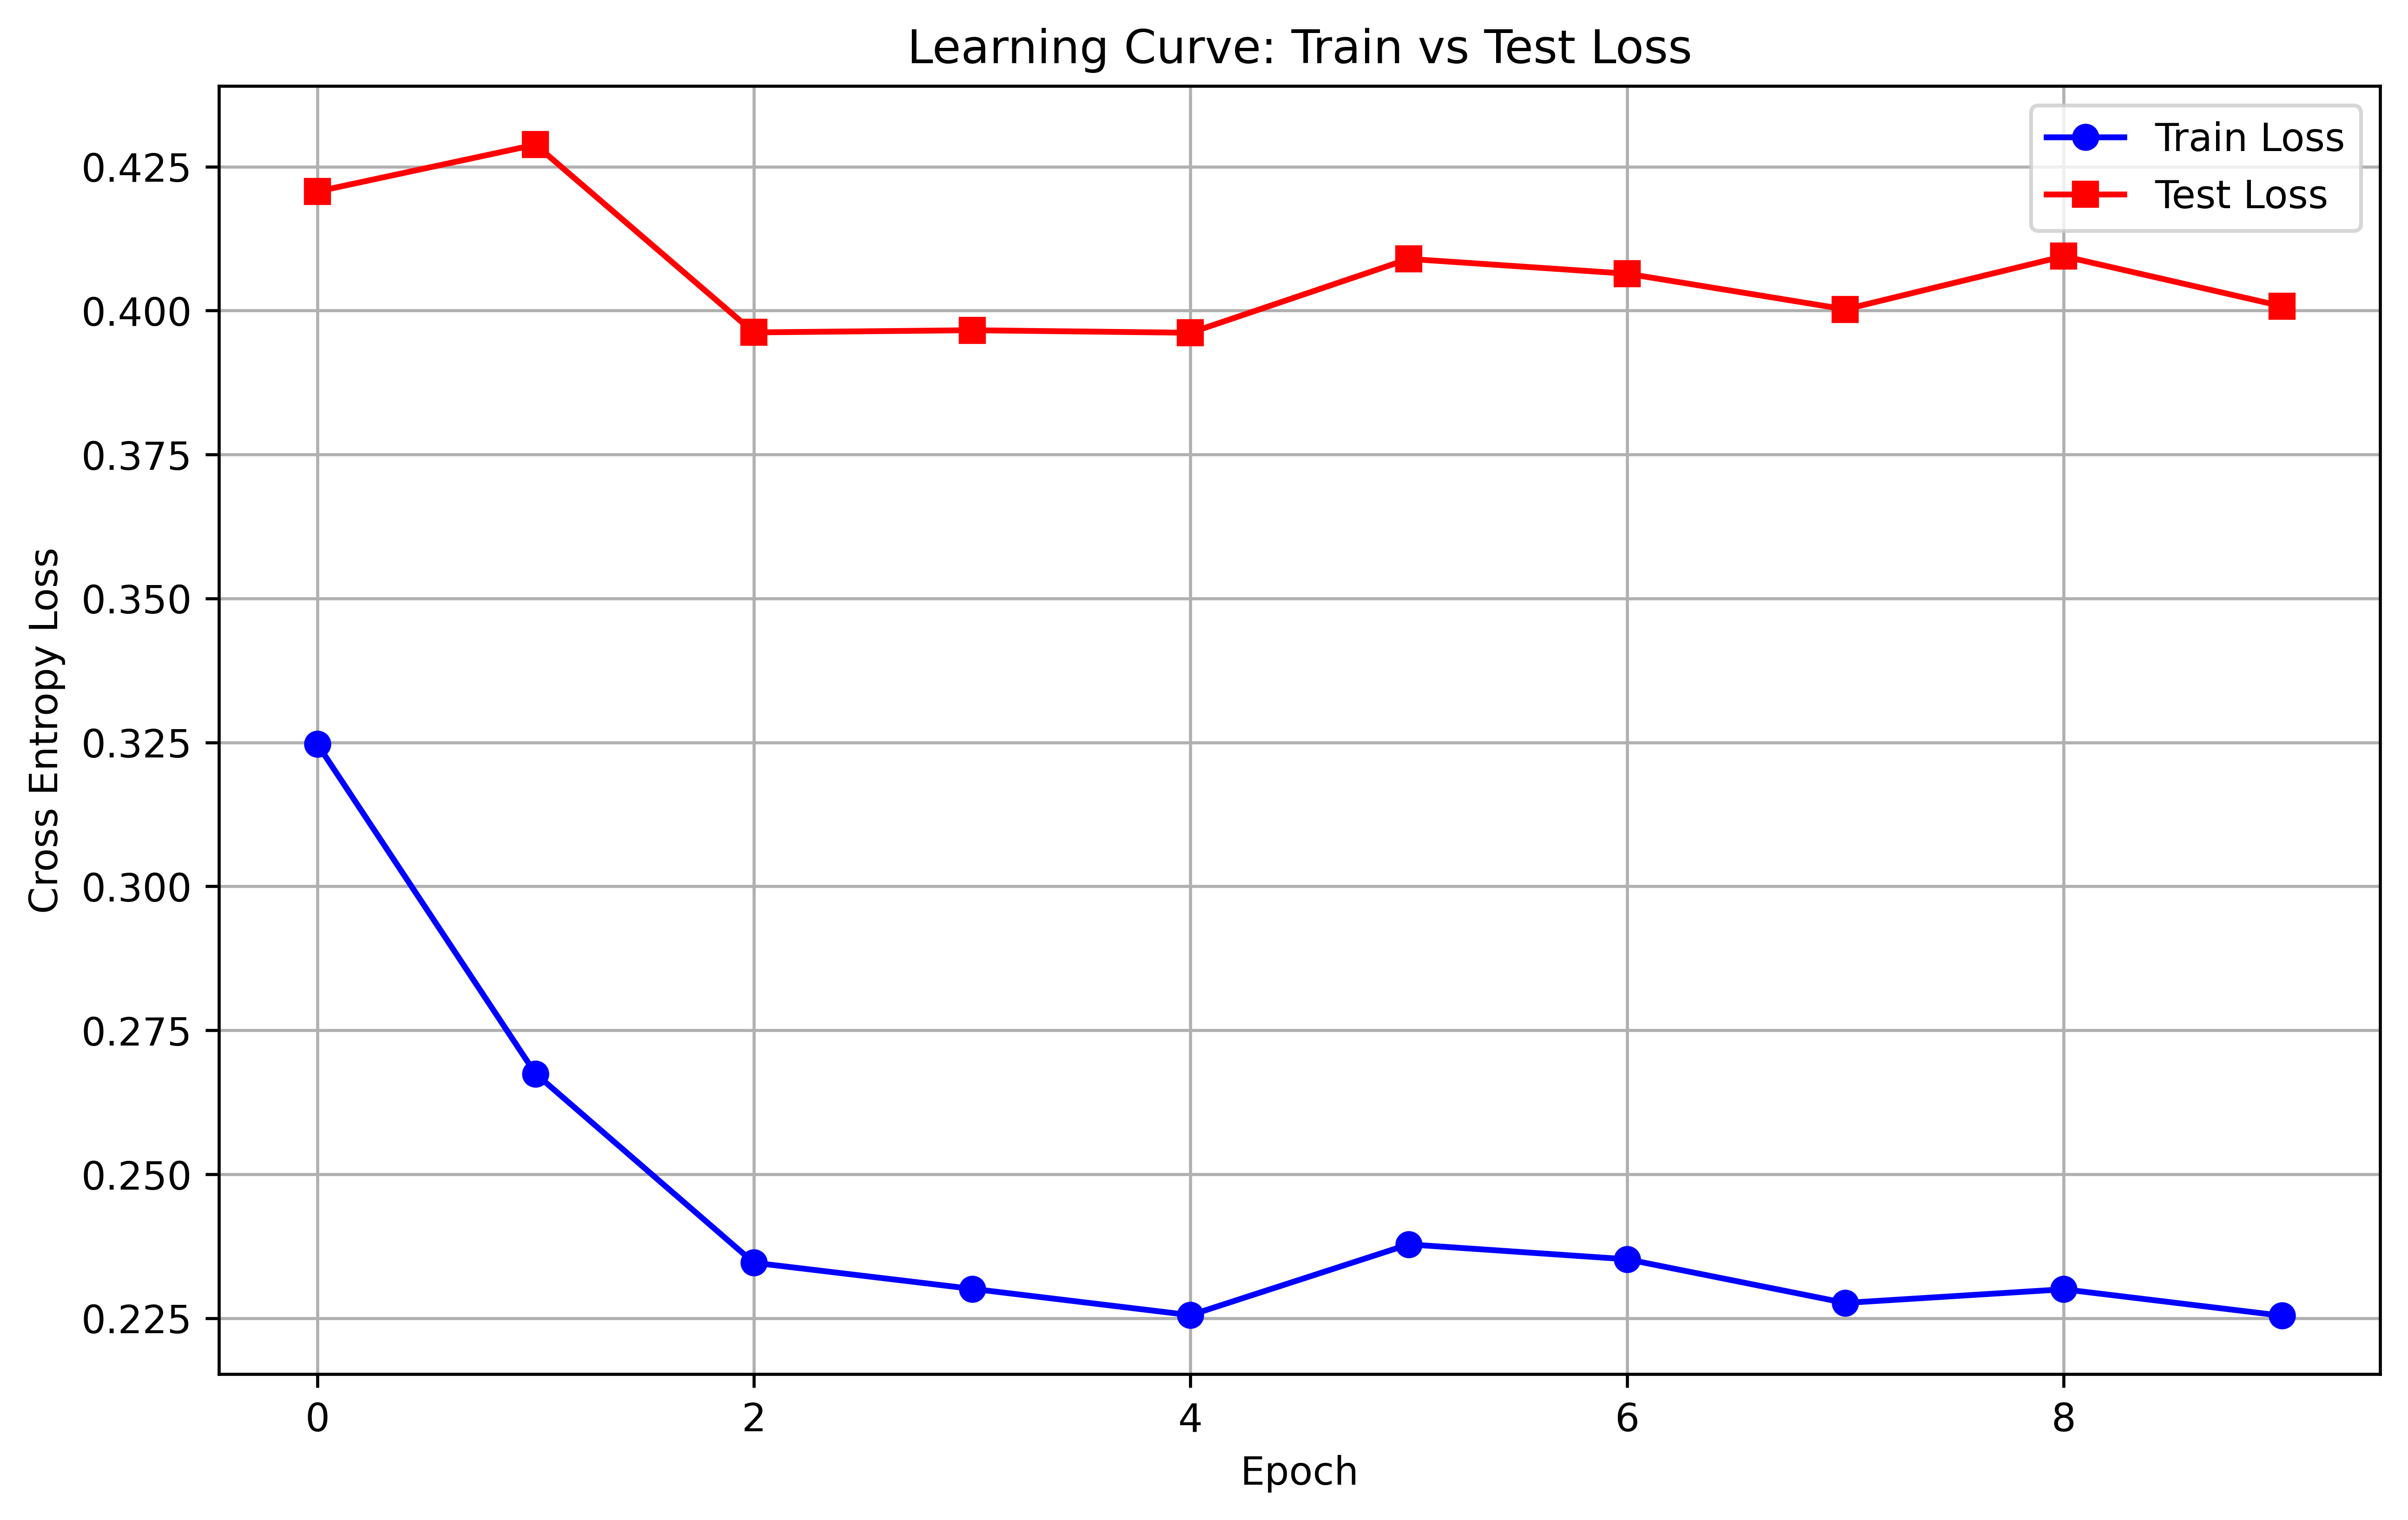

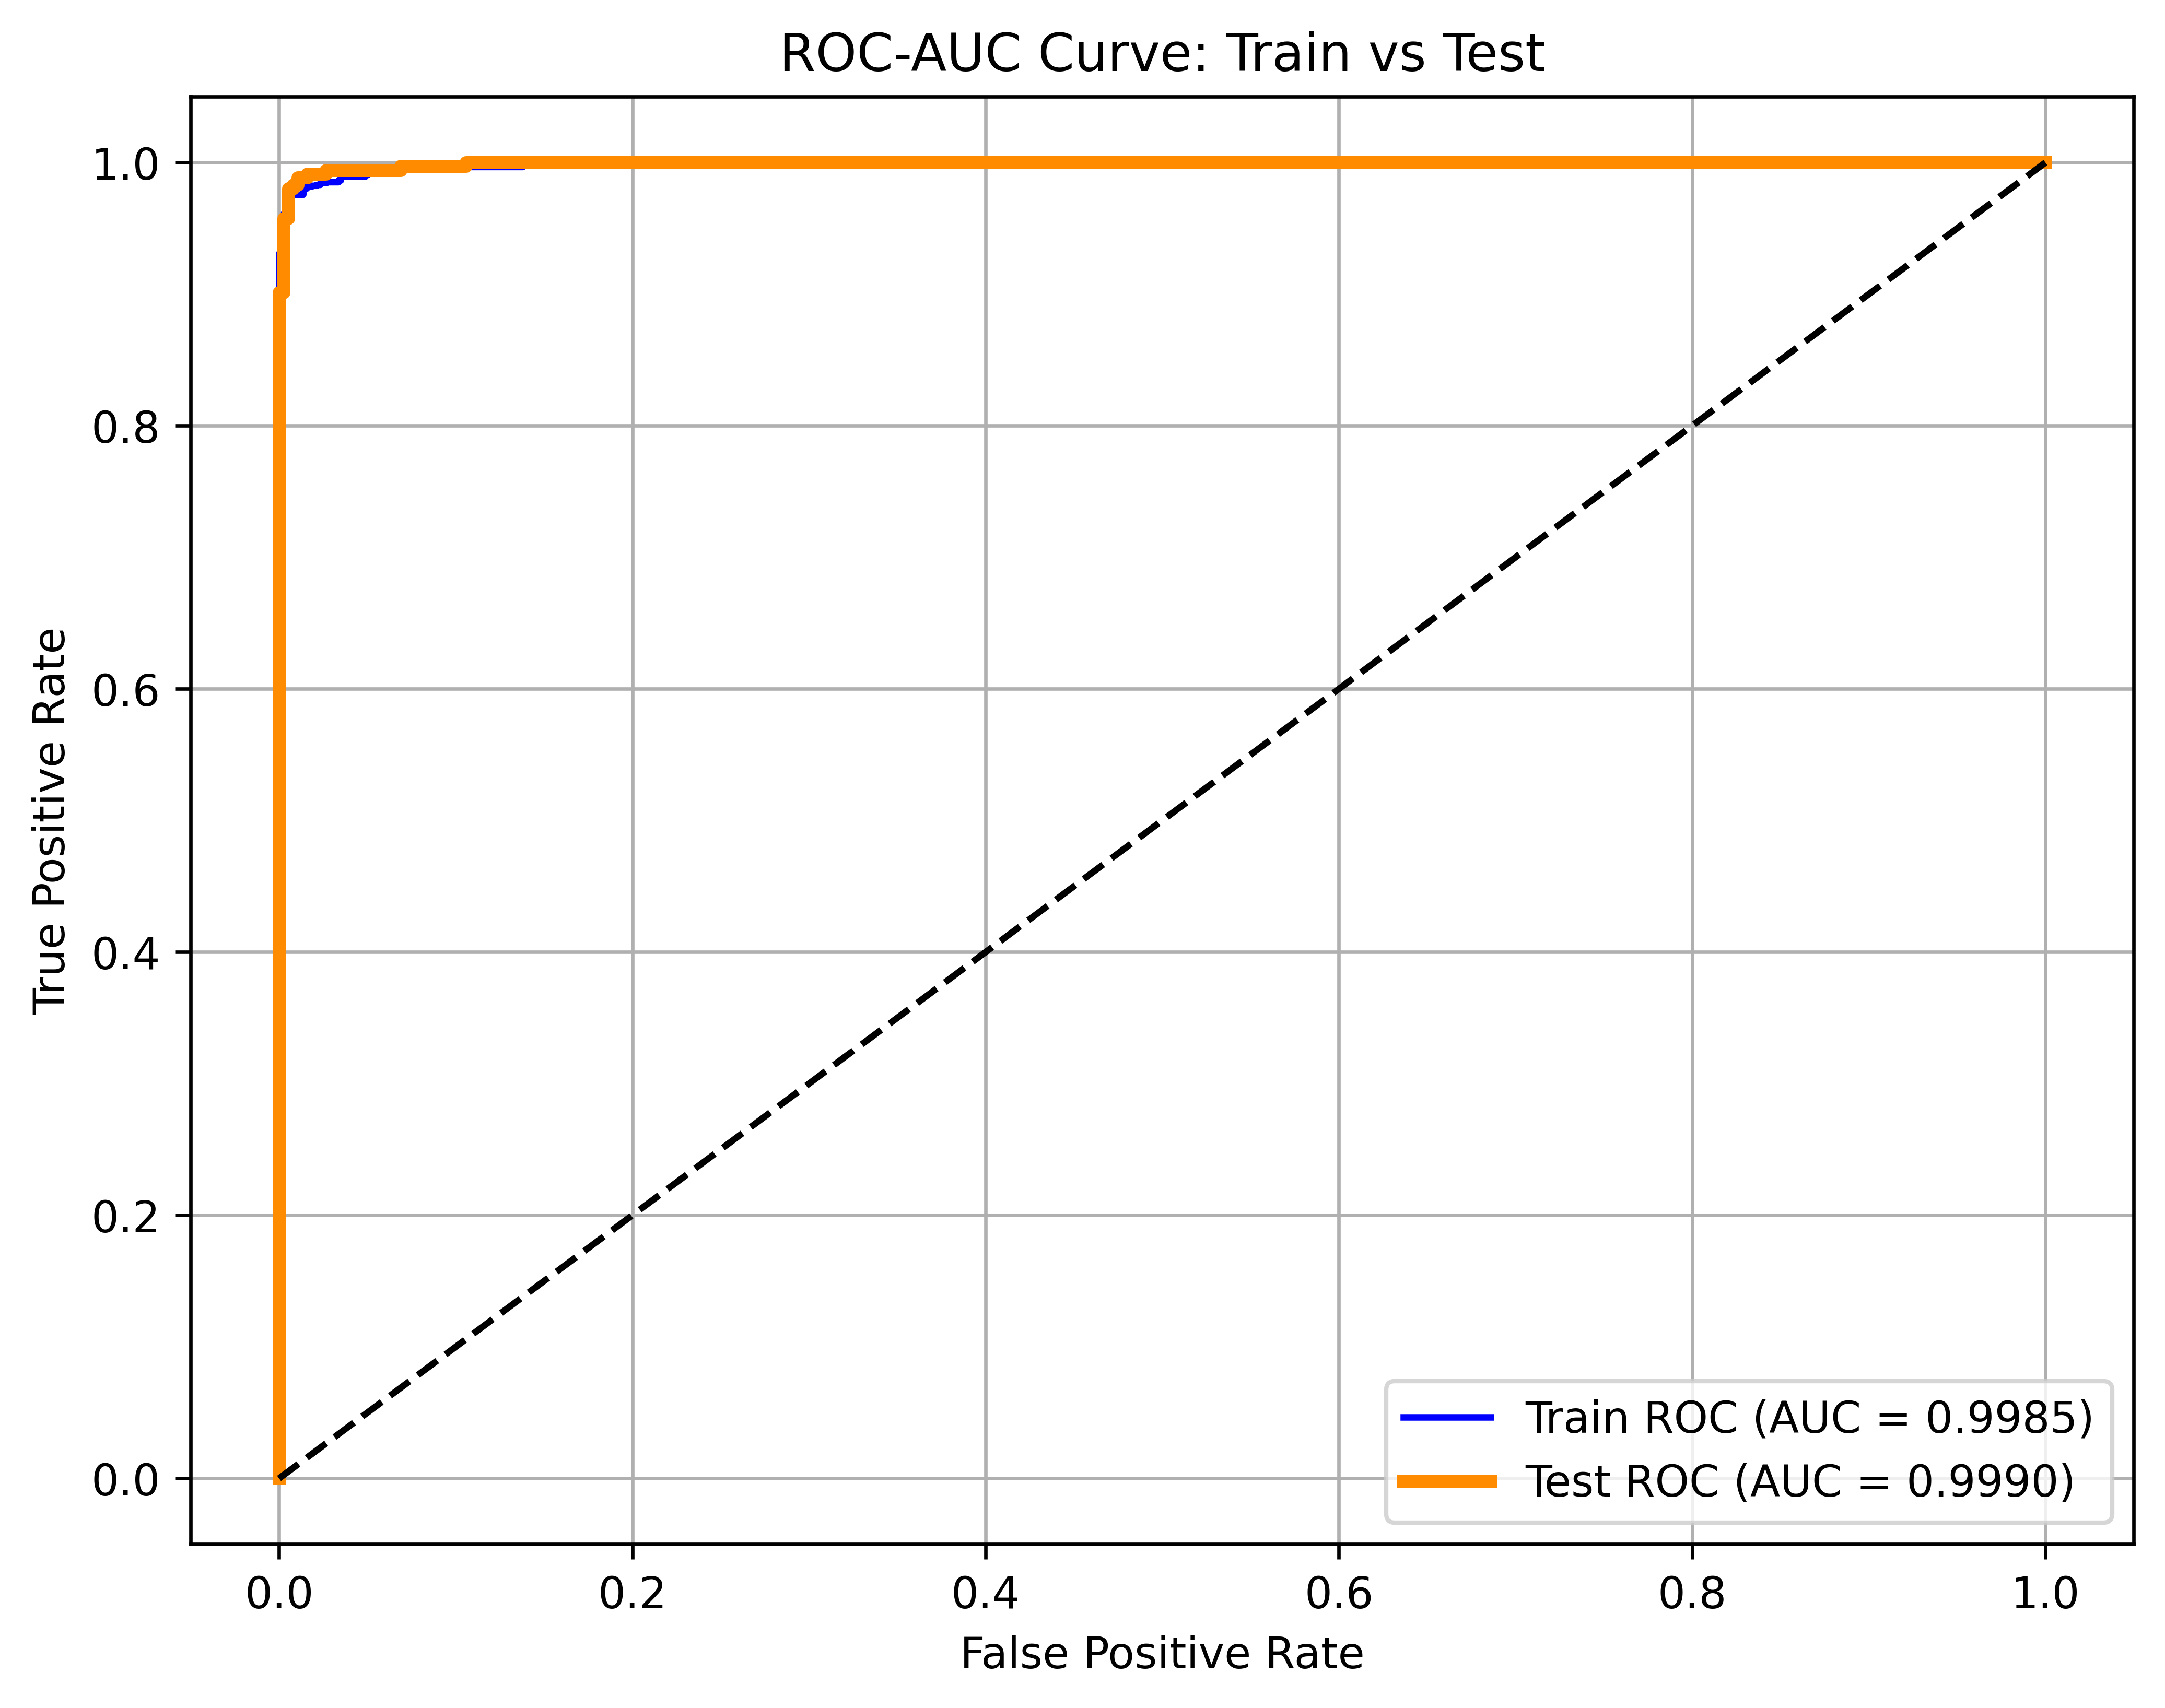

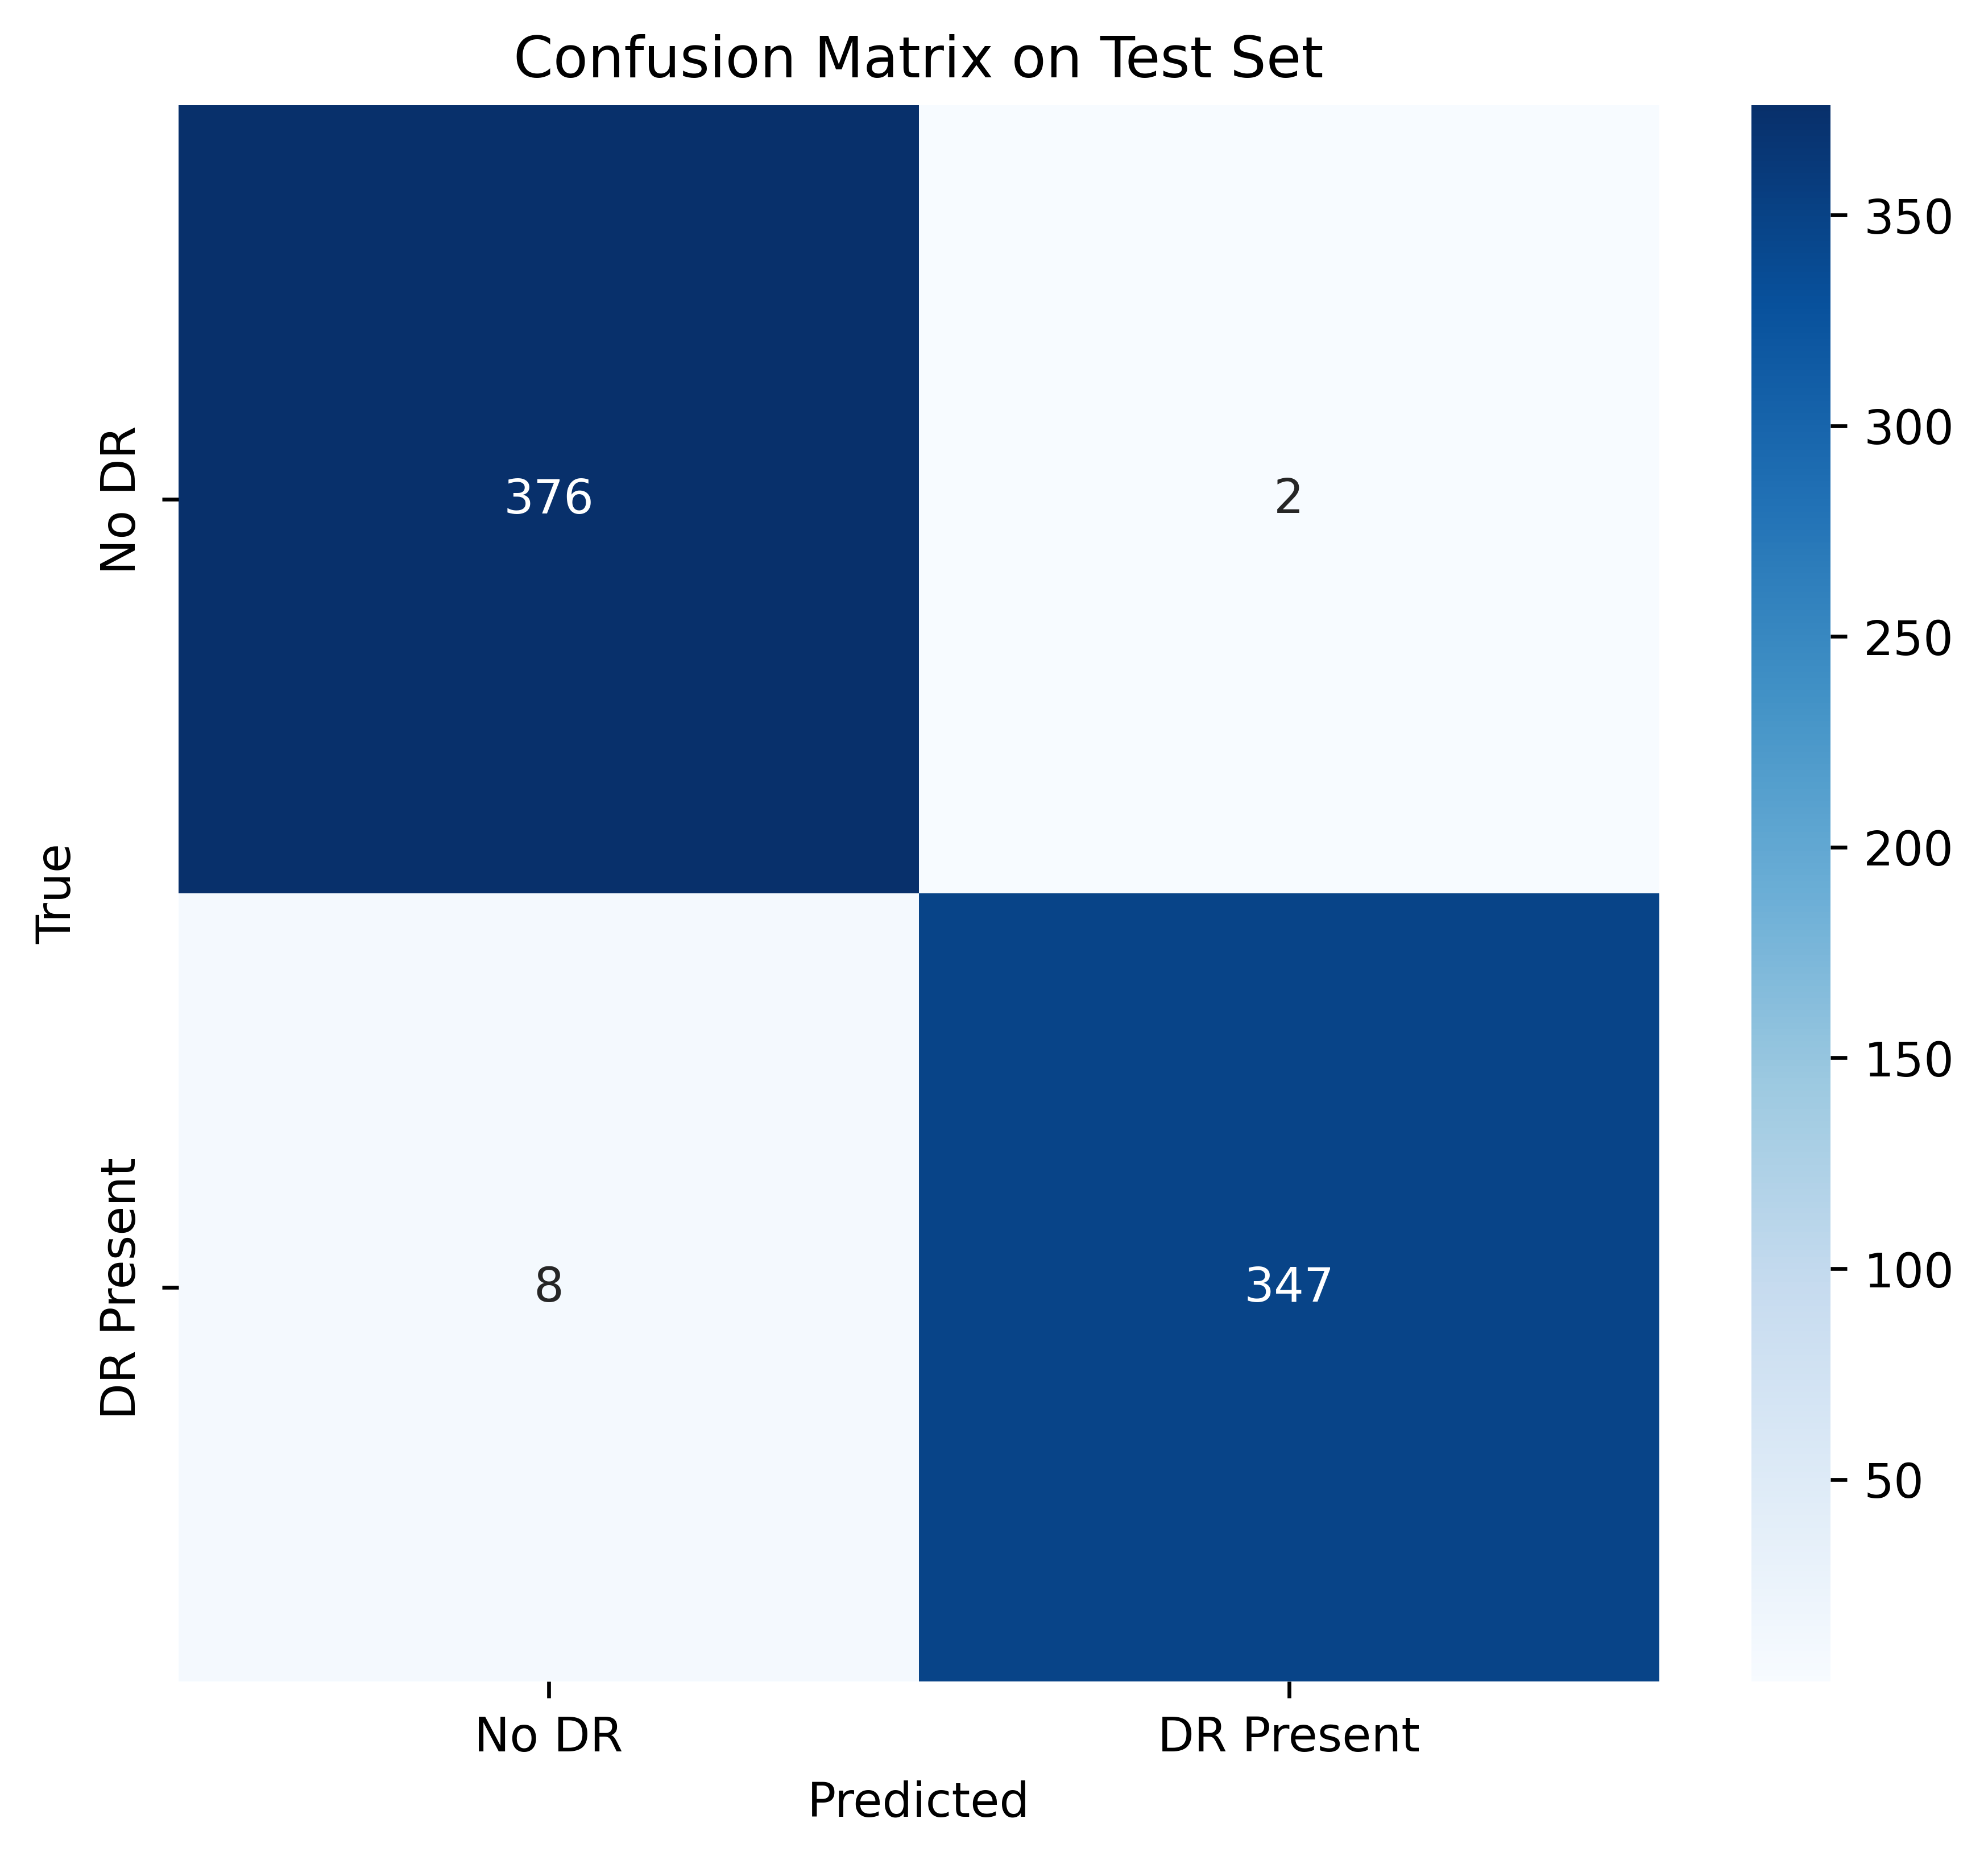

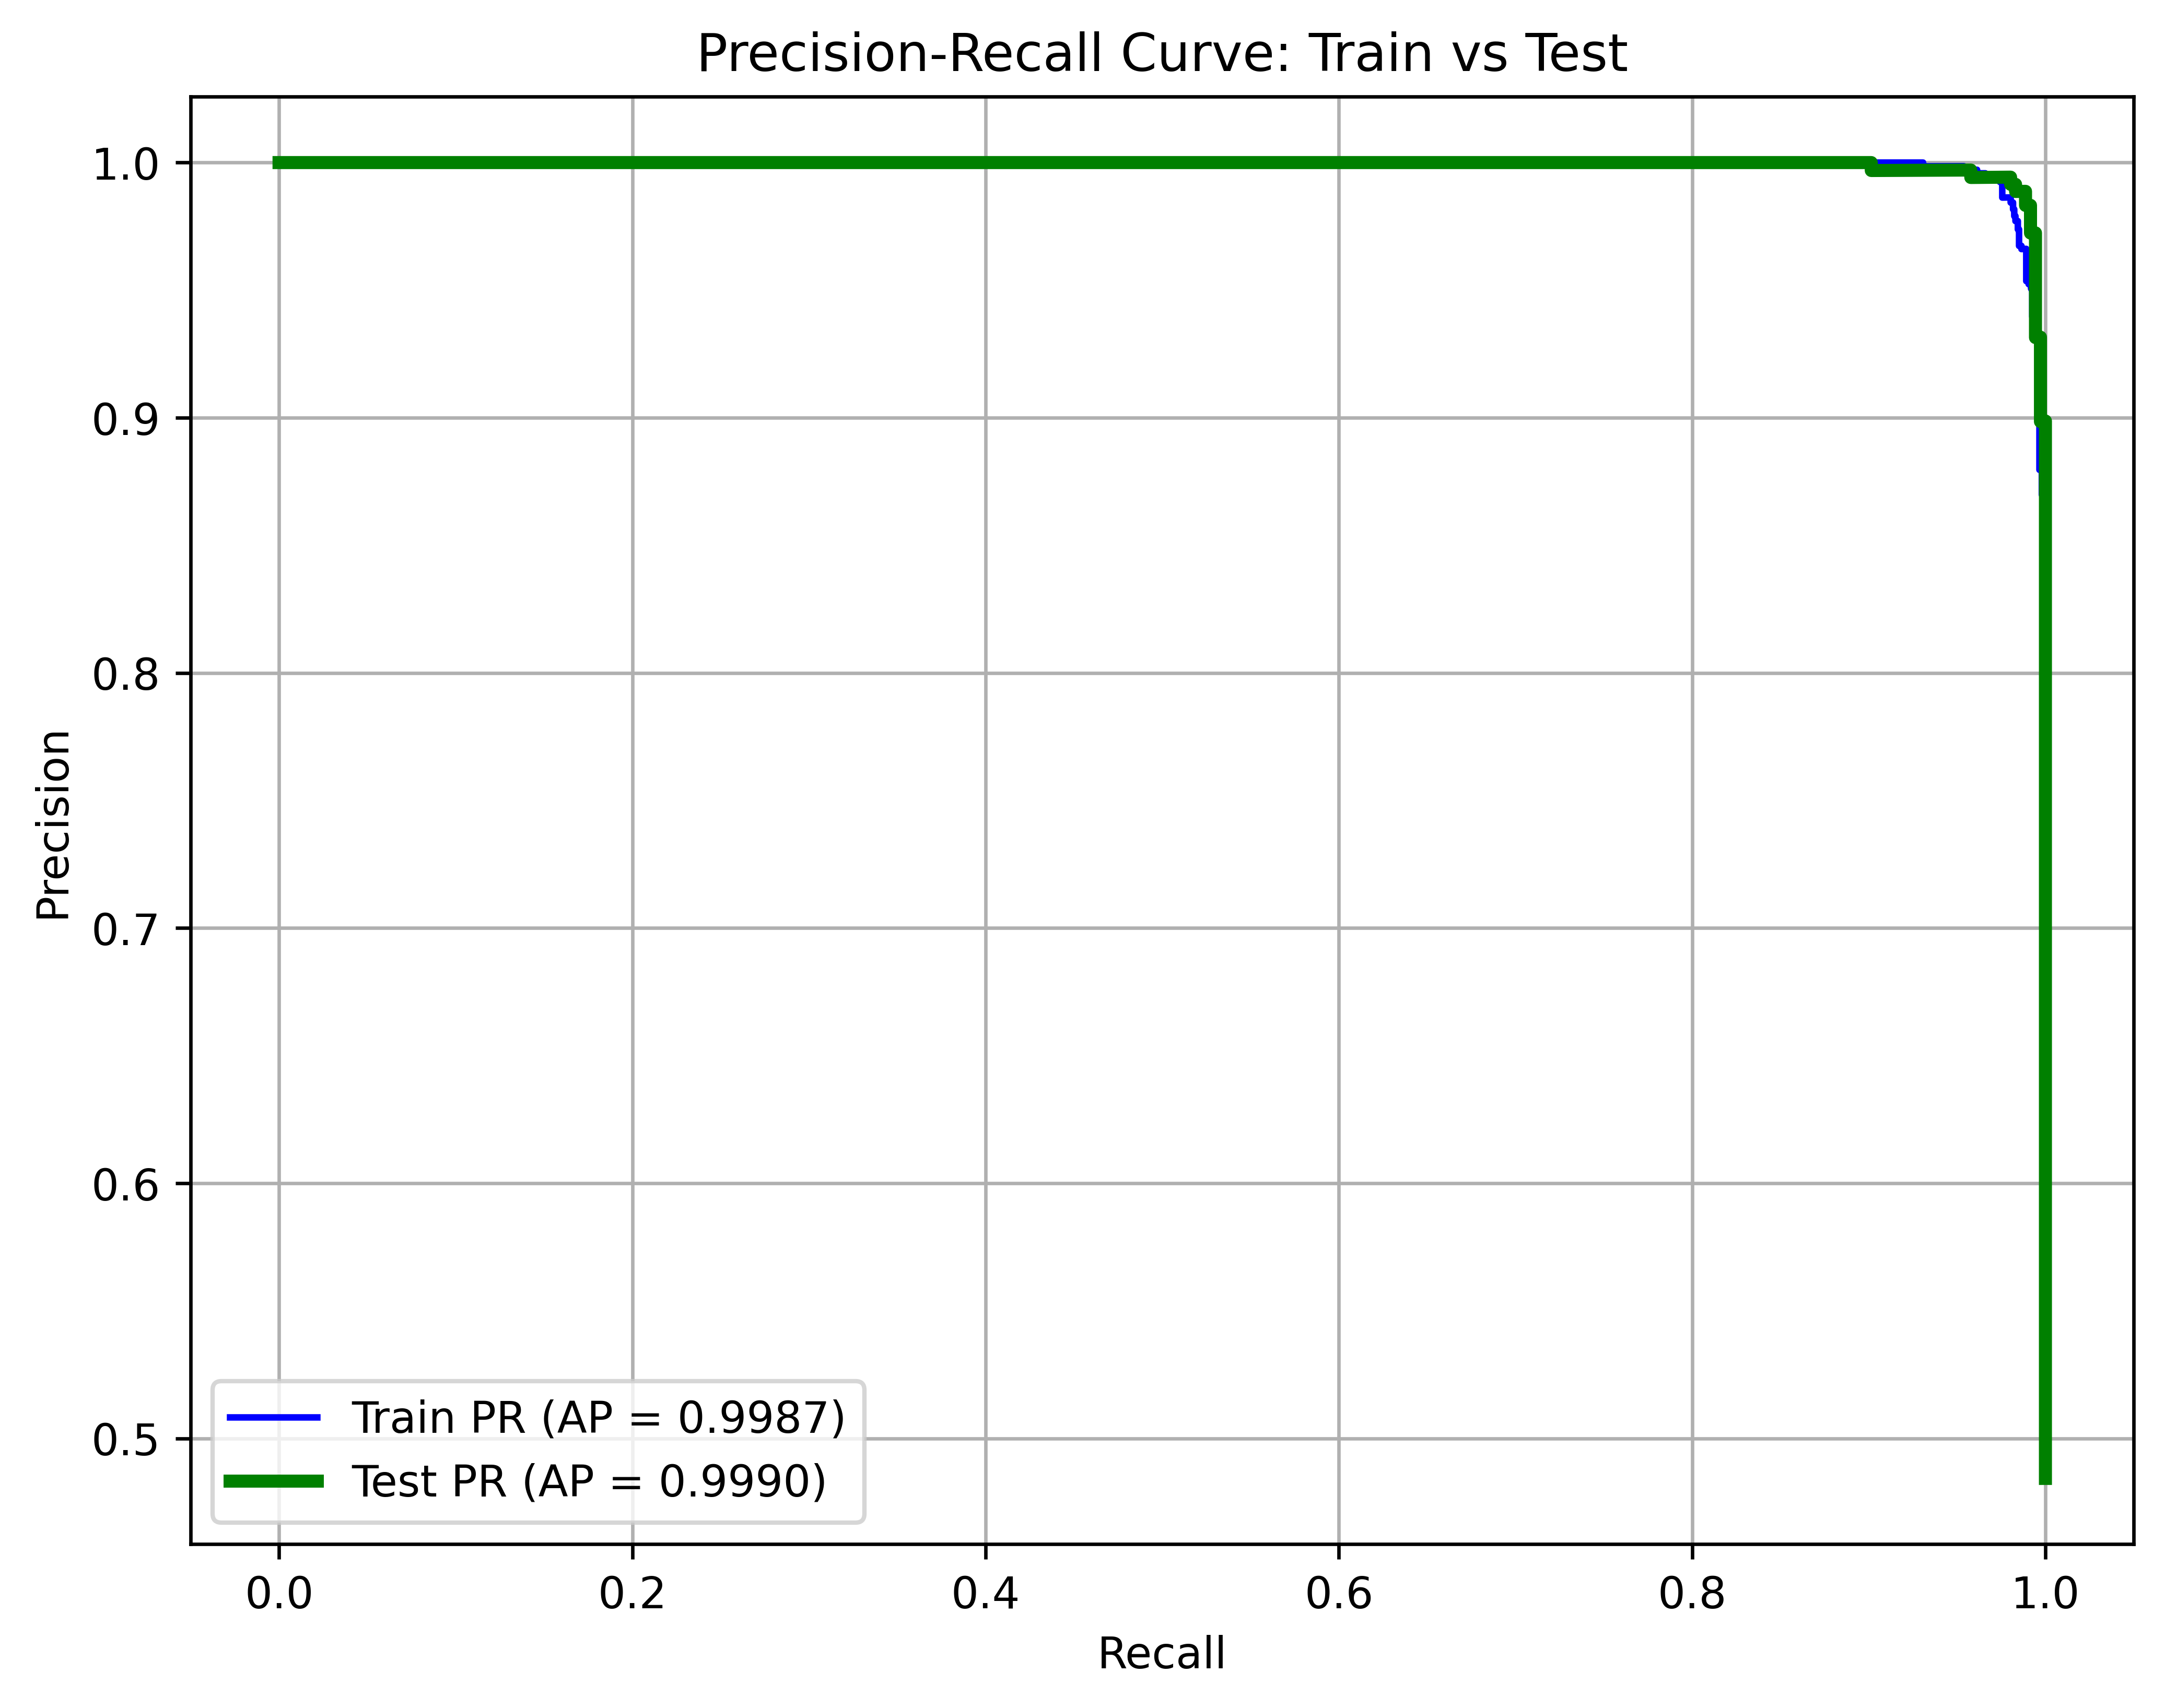


Binary classification task completed! All evaluations are based on the test set.
Test Accuracy: 0.9864
Test AUC: 0.9990
DR Recall (Sensitivity): 0.9775
DR Precision: 0.9943


In [15]:
model.load_state_dict(torch.load(best_model_path))
model.eval()
train_probs, train_labels = [], []
with torch.no_grad():
    for img, clin, label in train_loader:
        img, clin = img.to(device), clin.to(device)
        out = tta_predict(model, img, clin, flips=4)
        prob = out[:, 1].cpu().numpy()
        train_probs.extend(prob)
        train_labels.extend(label.cpu().numpy())

train_fpr, train_tpr, _ = roc_curve(train_labels, train_probs)
train_auc = auc(train_fpr, train_tpr)
train_precision, train_recall, _ = precision_recall_curve(train_labels, train_probs)
train_ap = average_precision_score(train_labels, train_probs)

test_probs, test_labels = [], []
with torch.no_grad():
    for img, clin, label in test_loader:
        img, clin = img.to(device), clin.to(device)
        out = tta_predict(model, img, clin, flips=8)
        prob = out[:, 1].cpu().numpy()
        test_probs.extend(prob)
        test_labels.extend(label.cpu().numpy())

test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs)
test_auc = auc(test_fpr, test_tpr)
test_precision, test_recall, _ = precision_recall_curve(test_labels, test_probs)
test_ap = average_precision_score(test_labels, test_probs)

# 1. CSV Report
report_dict = classification_report(test_labels, test_preds, output_dict=True, digits=4, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv('binary_dr_testset_report.csv', index=True)
print("The test set evaluation report has been saved：binary_dr_testset_report.csv")

# 2. Learning Curve
plt.figure(figsize=(10,6), dpi=600)
plt.plot(train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(test_losses, label='Test Loss', color='red', marker='s')
plt.title('Learning Curve: Train vs Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

# 3. ROC-AUC Curve
plt.figure(figsize=(8,6), dpi=600)
plt.plot(train_fpr, train_tpr, label=f'Train ROC (AUC = {train_auc:.4f})', color='blue')
plt.plot(test_fpr, test_tpr, label=f'Test ROC (AUC = {test_auc:.4f})', color='darkorange', linewidth=3)
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC-AUC Curve: Train vs Test')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# 4. Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7,6), dpi=600)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No DR', 'DR Present'],
            yticklabels=['No DR', 'DR Present'])
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 5. Precision-Recall Curve
plt.figure(figsize=(8,6), dpi=600)
plt.plot(train_recall, train_precision, label=f'Train PR (AP = {train_ap:.4f})', color='blue')
plt.plot(test_recall, test_precision, label=f'Test PR (AP = {test_ap:.4f})', color='green', linewidth=3)
plt.title('Precision-Recall Curve: Train vs Test')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

print("\n" + "="*80)
print("Binary classification task completed! All evaluations are based on the test set.")
print(f"Test Accuracy: {accuracy_score(test_labels, test_preds):.4f}")         
print(f"Test AUC: {test_auc:.4f}")                                              
print(f"DR Recall (Sensitivity): {recall_score(test_labels, test_preds):.4f}") 
print(f"DR Precision: {precision_score(test_labels, test_preds):.4f}")         
print("="*80)

# RAG for Interpretability

In [16]:
# Lightweight RAG module: Embed knowledge base, index with FAISS, retrieve evidence for predictions.
# Enhances explainability by linking predictions to medical facts.
from sentence_transformers import SentenceTransformer
import faiss
import torch
import numpy as np
from PIL import Image

# Load Sentence-BERT
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Curated knowledge base: 35 facts on DR stages, risks, treatments from reliable sources
knowledge_base = [

    "Diabetic retinopathy is a diabetes complication that affects the eyes and can lead to blindness.",
    "Early stages of diabetic retinopathy often have no symptoms.",
    "In mild nonproliferative retinopathy, microaneurysms occur.",
    "Moderate nonproliferative retinopathy involves blocked blood vessels.",
    "Severe nonproliferative retinopathy has many blocked vessels leading to oxygen deprivation.",
    "Proliferative retinopathy involves new abnormal blood vessel growth.",
    "Symptoms include blurry vision, floaters, and vision loss.",
    "Biomarkers include microaneurysms, hemorrhages, exudates, and neovascularization.",
    "Treatment for early stages focuses on blood sugar control.",
    "Laser treatment like pan-retinal photocoagulation is used for advanced stages.",
    "Anti-VEGF injections help reduce swelling and new vessel growth.",
    "Vitrectomy surgery may be needed for severe cases.",
    "Regular eye exams are crucial for early detection.",
    "High blood sugar damages retinal blood vessels over time.",
    "Hypertension and high cholesterol increase DR risk.",
    "Duration of diabetes correlates with DR severity.",
    "HbA1c levels above 7% increase DR progression risk.",
    "Diabetic macular edema is a common complication.",
    "Fundus photography is key for DR screening.",
    "OCT imaging helps detect retinal thickening.",
    
    "Mild NPDR (Grade 1) is characterized by at least one microaneurysm with no other lesions.",
    "Moderate NPDR (Grade 2) features extensive microaneurysms, dot-blot hemorrhages, cotton-wool spots, and venous beading in less than two quadrants.",
    "Severe NPDR (Grade 3) follows the 4-2-1 rule: hemorrhages in 4 quadrants, venous beading in 2, and IRMA in 1.",
    "Proliferative DR (Grade 4) includes neovascularization on the disc or elsewhere, with risk of vitreous hemorrhage.",
    "In moderate NPDR, blocked retinal vessels lead to ischemia and potential progression to severe stages.",
    "Cotton-wool spots in Grade 2 indicate nerve fiber layer infarcts due to capillary non-perfusion.",
    "Venous beading in moderate DR is a sign of retinal hypoxia and impending severe disease.",
    "HbA1c greater than 7% is strongly associated with faster progression from moderate to severe NPDR.",
    "Early detection of Grade 2 changes via fundus exam can prevent vision loss through timely intervention.",
    "Anti-VEGF therapy is effective for macular edema complicating moderate NPDR.",
    "Duration of diabetes over 10 years increases likelihood of moderate retinopathy.",
    "Hypertension exacerbates hemorrhages in Grade 2 DR.",
    "No apparent retinopathy (Grade 0) shows no observable abnormalities on dilated exam.",
    "International Clinical DR Severity Scale defines mild, moderate, severe NPDR, and PDR.",
    "ETDRS study provides evidence-based grading for DR clinical trials."
]

# Encode knowledge base into embeddings (384 dims each).
kb_embeds = sbert_model.encode(knowledge_base)

# Build FAISS index for fast L2 similarity search.
dimension = kb_embeds.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(kb_embeds.astype(np.float32))
          
# Retrieval function: Semantic search with top-k and distance threshold.
# Filters low-relevance items (dist < threshold) for quality evidence.
def retrieve_evidence(query, k=5, threshold=0.8):
    query_emb = sbert_model.encode([query])
    D, I = index.search(query_emb.astype(np.float32), k)
    evidence = []
    for dist, idx in zip(D[0], I[0]):
        if dist < threshold:  
            evidence.append(knowledge_base[idx])
    return evidence[:3]

# Map prediction index to human-readable grade names (for explanation only)
grade_names = ['No DR', 'Mild NPDR', 'Moderate NPDR', 'Severe NPDR', 'Proliferative DR']

# Randomly select a sample for demonstration (you can change sample_idx)
sample_idx = 0
sample = df.iloc[sample_idx]

# Get image, clinical features and true label from full_dataset
img, clin, true_label = full_dataset[sample_idx]
img = img.unsqueeze(0).to(device)      # Add batch dimension
clin = clin.unsqueeze(0).to(device)

# Model prediction (0 or 1 for binary, but we keep original 5-class logits)
with torch.no_grad():
    logits = model(img, clin)
    pred = torch.argmax(logits, dim=1).item()        # 0-4 for 5-class
    binary_pred = 1 if pred > 0 else 0               # Convert to binary for display

# Convert numeric grade to English name
pred_grade_name = grade_names[pred]

# === Craft a professional, grade-specific query ===
# This is the key: ask for specific lesions, risk factors and treatment
query = (f"A patient has been diagnosed with {pred_grade_name} (Grade {pred}) "
         f"diabetic retinopathy by deep learning model. "
         f"Patient details: age {int(sample['age'])}, "
         f"diabetes duration {int(sample['duration_diabetes'])} years, "
         f"HbA1c {sample['hba1c']:.2f}%, "
         f"systolic BP {int(sample['blood_pressure_systolic'])} mmHg. "
         f"Please explain the characteristic retinal lesions for this grade, "
         f"why this patient likely reached this stage based on clinical risk factors, "
         f"and provide evidence-based next steps (follow-up frequency, treatment) "
         f"according to ETDRS and International Clinical DR Severity Scale.")

# Retrieve the most relevant medical facts
evidence = retrieve_evidence(query, k=6, threshold=0.75)   # Slightly looser threshold for richer output

# === Print beautiful, clinical-grade explanation ===
print("="*80)
print("AI DIAGNOSIS REPORT (with Evidence from International Guidelines)")
print("="*80)
print(f"Patient ID          : {sample['id_code']}")
print(f"Model Prediction    : {pred_grade_name} (Grade {pred}) → {'DR Present' if binary_pred == 1 else 'No DR'}")
print(f"True Label          : {'DR Present' if true_label.item() == 1 else 'No DR'}")
print(f"Clinical Profile    : Age {int(sample['age'])}, "
      f"Diabetes {int(sample['duration_diabetes'])} yrs, "
      f"HbA1c {sample['hba1c']:.2f}%, BP {int(sample['blood_pressure_systolic'])} mmHg")
print("-"*80)
print("EVIDENCE-BASED EXPLANATION (retrieved from medical knowledge base):")
print("-"*80)
for i, ev in enumerate(evidence, 1):
    print(f"{i}. {ev}")
print("-"*80)
if pred == 0:
    print("RECOMMENDATION: Continue routine annual screening. Excellent glycemic control maintained.")
elif pred == 1:
    print("RECOMMENDATION: Mild NPDR → Annual or 6-monthly fundus exam. Optimize HbA1c <7.0%.")
elif pred == 2:
    print("RECOMMENDATION: Moderate NPDR → Screening every 6 months. Strict BP and glycemic control.")
elif pred == 3:
    print("RECOMMENDATION: Severe NPDR → Urgent ophthalmology referral. High risk of progression.")
elif pred == 4:
    print("RECOMMENDATION: Proliferative DR → Immediate anti-VEGF or laser treatment required.")
print("="*80)

AI DIAGNOSIS REPORT (with Evidence from International Guidelines)
Patient ID          : 000c1434d8d7
Model Prediction    : Mild NPDR (Grade 1) → DR Present
True Label          : DR Present
Clinical Profile    : Age 1, Diabetes 0 yrs, HbA1c 1.18%, BP 0 mmHg
--------------------------------------------------------------------------------
EVIDENCE-BASED EXPLANATION (retrieved from medical knowledge base):
--------------------------------------------------------------------------------
1. In moderate NPDR, blocked retinal vessels lead to ischemia and potential progression to severe stages.
2. Duration of diabetes over 10 years increases likelihood of moderate retinopathy.
3. Diabetic retinopathy is a diabetes complication that affects the eyes and can lead to blindness.
--------------------------------------------------------------------------------
RECOMMENDATION: Mild NPDR → Annual or 6-monthly fundus exam. Optimize HbA1c <7.0%.
